In [1]:
import pandas as pd

df = pd.read_csv('customer_segmentation.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

FileNotFoundError: [Errno 2] No such file or directory: 'customer_segmentation.csv'

In [2]:
import pandas as pd
import numpy as np

# Create a synthetic dataset to mimic 'customer_segmentation.csv'
np.random.seed(42)
data = {
    'CustomerID': range(1, 201),
    'Gender': np.random.choice(['Male', 'Female'], 200),
    'Age': np.random.randint(18, 70, 200),
    'Annual Income (k$)': np.random.randint(15, 140, 200),
    'Spending Score (1-100)': np.random.randint(1, 100, 200)
}
df_synthetic = pd.DataFrame(data)
df_synthetic.to_csv('customer_segmentation.csv', index=False)

# Load the dataset (now it exists)
df = pd.read_csv('customer_segmentation.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

First 5 rows of the DataFrame:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   49                  68                      86
1           2  Female   56                  22                      57
2           3    Male   66                  41                      29
3           4    Male   69                  41                      78
4           5    Male   49                 112                      92

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Descrip

In [3]:
from sklearn.preprocessing import StandardScaler

# 1. Drop the 'CustomerID' column
df_processed = df.drop('CustomerID', axis=1)

# 2. Convert the categorical 'Gender' column into numerical format using one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=['Gender'], drop_first=True, dtype=int) # drop_first=True to avoid multicollinearity

# 3. Identify the numerical features for scaling
numerical_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# 4. Instantiate and apply StandardScaler to numerical features
scaler = StandardScaler()
df_processed[numerical_features] = scaler.fit_transform(df_processed[numerical_features])

# 5. Print the head of the processed and scaled DataFrame
print("First 5 rows of the processed and scaled DataFrame:")
print(df_processed.head())

First 5 rows of the processed and scaled DataFrame:
        Age  Annual Income (k$)  Spending Score (1-100)  Gender_Male
0  0.300025           -0.247759                1.232084            1
1  0.757082           -1.509177                0.245055            0
2  1.410020           -0.988157               -0.707938            1
3  1.605902           -0.988157                0.959800            1
4  0.300025            0.958815                1.436297            1


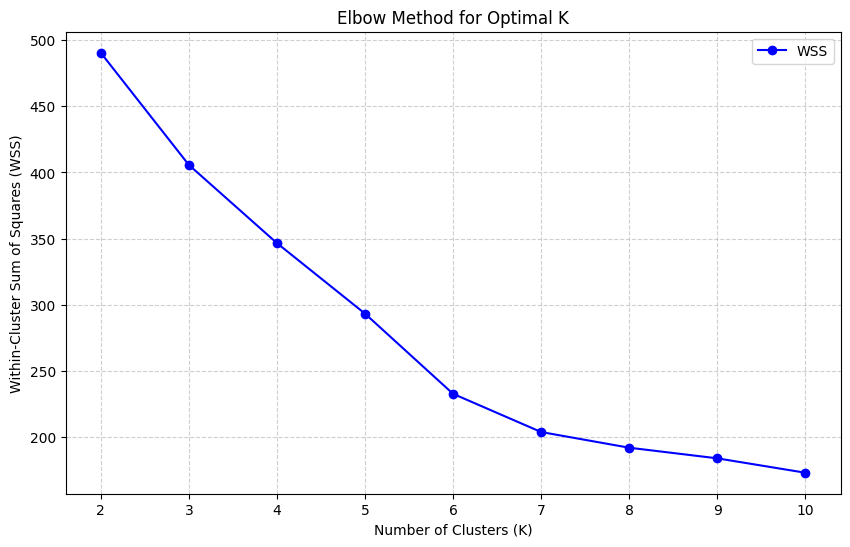

Elbow method plot generated successfully.


In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create an empty list to store WSS values
wss = []

# Define a range of k values
k_range = range(2, 11) # From 2 to 10

# Loop through each k in the defined range
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_processed)
    wss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wss, marker='o', linestyle='-', color='blue', label='WSS')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WSS)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("Elbow method plot generated successfully.")

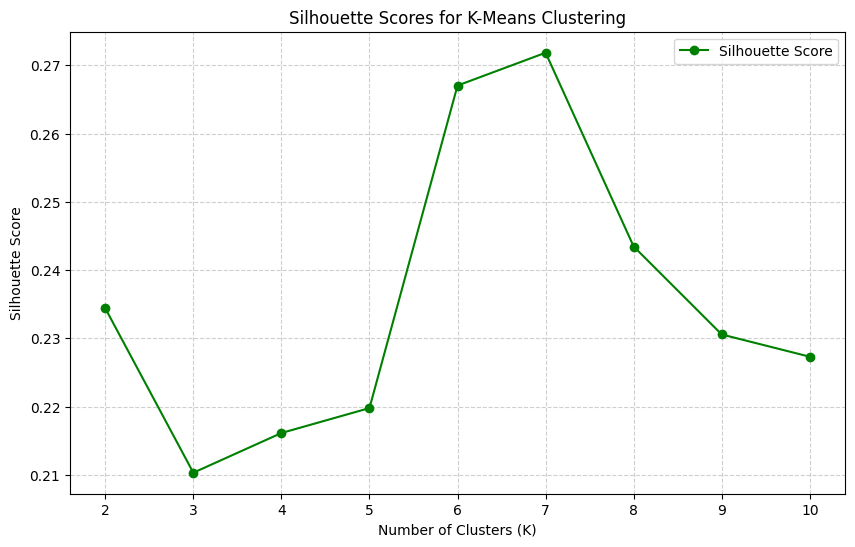

Silhouette scores plot generated successfully.


In [5]:
from sklearn.metrics import silhouette_score

# Create an empty list to store silhouette scores
silhouette_scores = []

# Define a range of k values (same as elbow method)
k_range = range(2, 11)

# Loop through each k in the defined range
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_processed)
    labels = kmeans.labels_
    score = silhouette_score(df_processed, labels)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-', color='green', label='Silhouette Score')
plt.title('Silhouette Scores for K-Means Clustering')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("Silhouette scores plot generated successfully.")

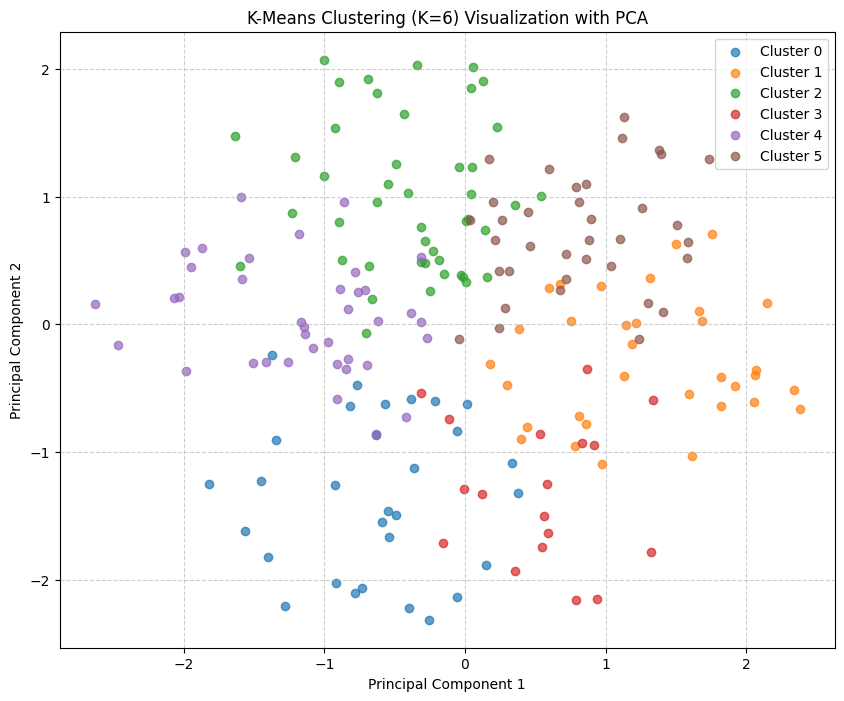

K-Means clustering with K=6 applied and visualized using PCA.


In [6]:
from sklearn.decomposition import PCA

# Optimal K value based on previous analysis
optimal_k = 6

# Apply K-Means with the optimal K
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_optimal.fit(df_processed)
df_processed['KMeans_Cluster'] = kmeans_optimal.labels_

# Apply PCA for dimensionality reduction to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_processed.drop('KMeans_Cluster', axis=1))

# Create a DataFrame for PCA results
df_pca = pd.DataFrame(data = X_pca, columns = ['PCA_Component_1', 'PCA_Component_2'])
df_pca['KMeans_Cluster'] = df_processed['KMeans_Cluster']

# Visualize the K-Means clusters using PCA components
plt.figure(figsize=(10, 8))
for cluster_id in sorted(df_pca['KMeans_Cluster'].unique()):
    subset = df_pca[df_pca['KMeans_Cluster'] == cluster_id]
    plt.scatter(subset['PCA_Component_1'], subset['PCA_Component_2'],
                label=f'Cluster {cluster_id}', alpha=0.7)

plt.title(f'K-Means Clustering (K={optimal_k}) Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"K-Means clustering with K={optimal_k} applied and visualized using PCA.")

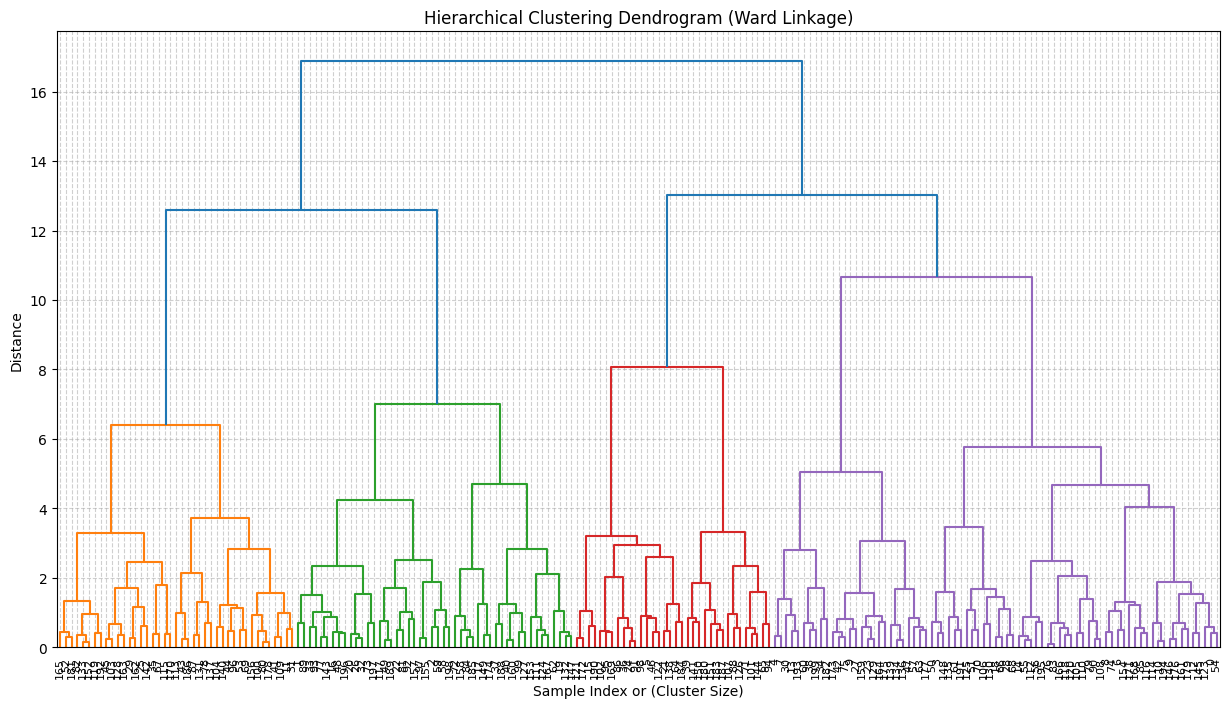

Dendrogram with Ward linkage generated successfully.


In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Compute the linkage matrix for Hierarchical Clustering using 'ward' method
# We'll use df_processed as the data for clustering
Z_ward = linkage(df_processed.drop('KMeans_Cluster', axis=1), method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(
    Z_ward,
    leaf_rotation=90.,  # rotates the x-axis labels
    leaf_font_size=8.,  # font size for the x-axis labels
    color_threshold=None # shows all clusters
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Dendrogram with Ward linkage generated successfully.")

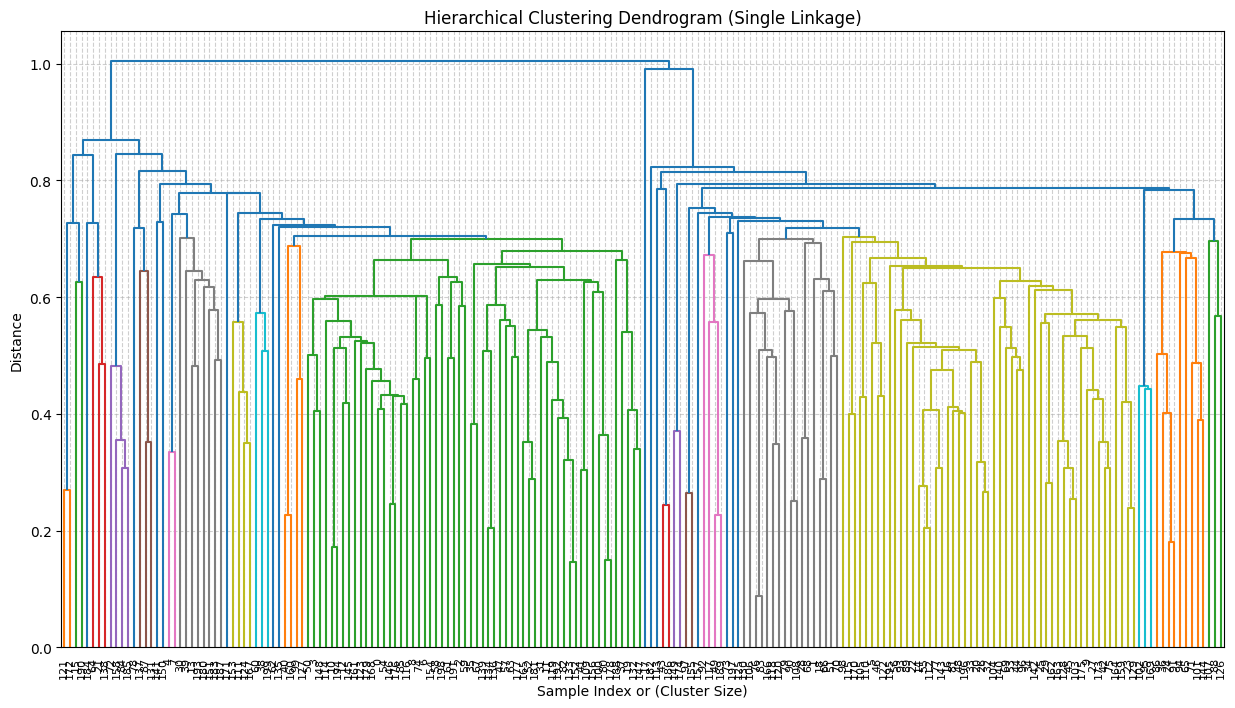

Dendrogram with Single Linkage generated successfully.


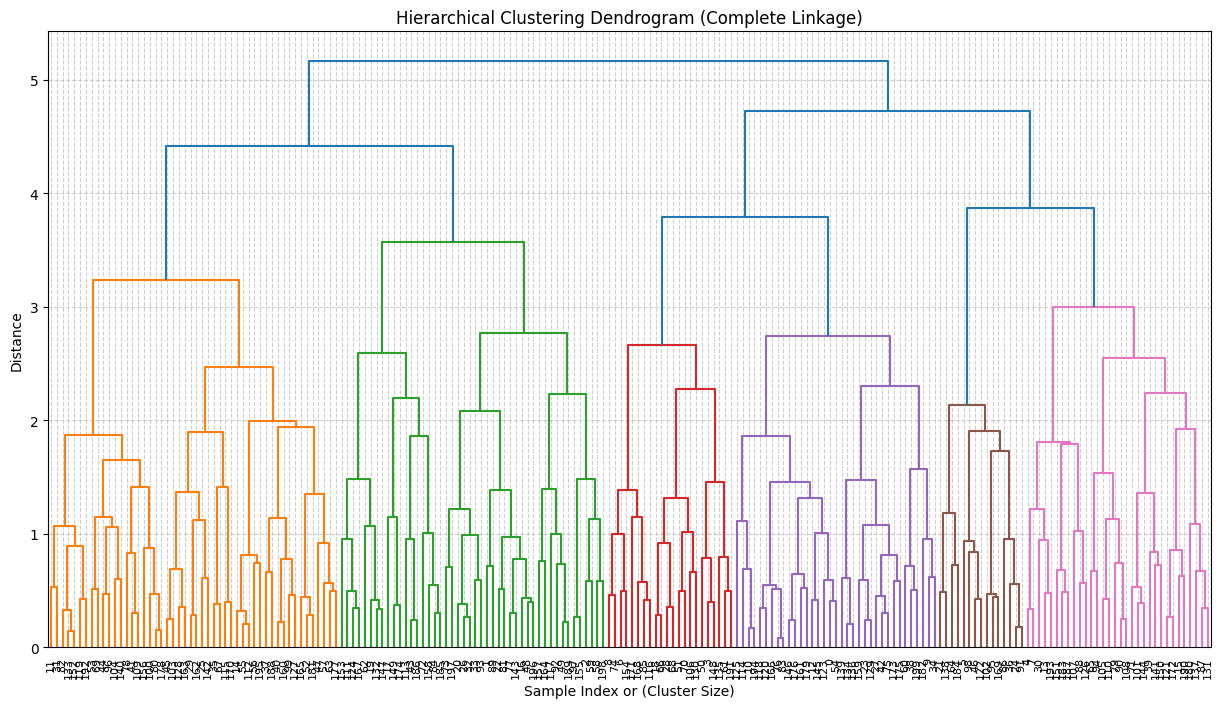

Dendrogram with Complete Linkage generated successfully.


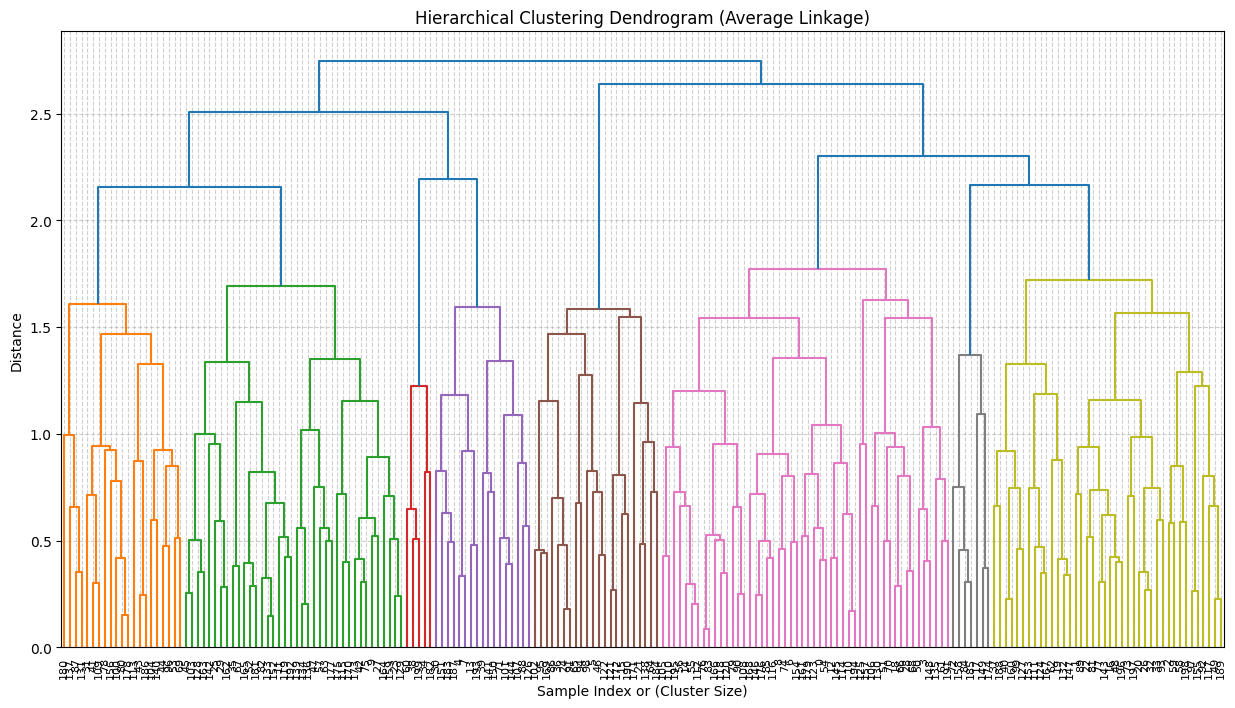

Dendrogram with Average Linkage generated successfully.


In [8]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Prepare data for hierarchical clustering (excluding the KMeans_Cluster column)
X_hierarchical = df_processed.drop('KMeans_Cluster', axis=1)

# Define different linkage methods
linkage_methods = {'single': 'Single Linkage', 'complete': 'Complete Linkage', 'average': 'Average Linkage'}

# Loop through each linkage method and plot the dendrogram
for method_name, title_name in linkage_methods.items():
    # Compute the linkage matrix
    Z = linkage(X_hierarchical, method=method_name)

    # Plot the dendrogram
    plt.figure(figsize=(15, 8))
    dendrogram(
        Z,
        leaf_rotation=90.,  # rotates the x-axis labels
        leaf_font_size=8.,  # font size for the x-axis labels
        color_threshold=None # shows all clusters
    )
    plt.title(f'Hierarchical Clustering Dendrogram ({title_name})')
    plt.xlabel('Sample Index or (Cluster Size)')
    plt.ylabel('Distance')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    print(f"Dendrogram with {title_name} generated successfully.")


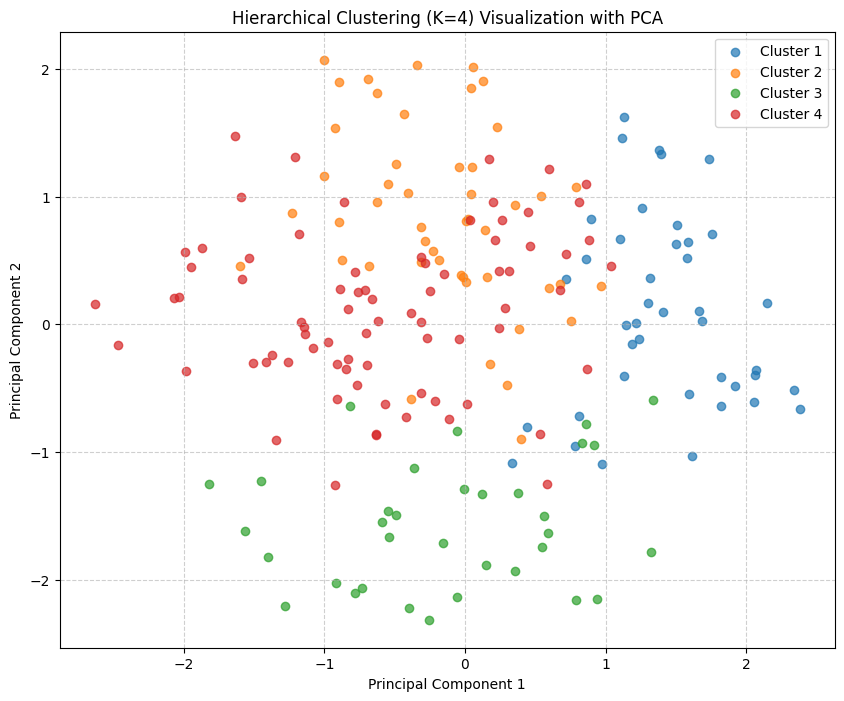

Hierarchical clustering with 4 clusters applied and visualized using PCA.


In [9]:
from scipy.cluster.hierarchy import fcluster
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Based on dendrogram analysis, let's choose an optimal number of clusters (e.g., 4) for visualization
# For Ward linkage, a cut-off at a distance where the largest vertical drop is observed often gives a good estimate.
# Recompute Z_ward to ensure it's fresh after previous operations if needed, though X_hierarchical is already prepared.
Z_ward = linkage(X_hierarchical, method='ward')

optimal_n_clusters_hierarchical = 4

# Assign clusters based on the chosen number of clusters
# criterion='maxclust' means forming exactly 't' clusters
clusters_hierarchical = fcluster(Z_ward, optimal_n_clusters_hierarchical, criterion='maxclust')

# Add the hierarchical cluster labels to a temporary DataFrame for PCA
df_hierarchical_clustered = X_hierarchical.copy()
df_hierarchical_clustered['Hierarchical_Cluster'] = clusters_hierarchical

# Apply PCA for dimensionality reduction to 2 components (excluding the cluster column)
pca_hierarchical = PCA(n_components=2)
X_pca_hierarchical = pca_hierarchical.fit_transform(df_hierarchical_clustered.drop('Hierarchical_Cluster', axis=1))

# Create a DataFrame for PCA results
df_pca_hierarchical = pd.DataFrame(data = X_pca_hierarchical, columns = ['PCA_Component_1', 'PCA_Component_2'])
df_pca_hierarchical['Hierarchical_Cluster'] = df_hierarchical_clustered['Hierarchical_Cluster']

# Visualize the Hierarchical clusters using PCA components
plt.figure(figsize=(10, 8))
for cluster_id in sorted(df_pca_hierarchical['Hierarchical_Cluster'].unique()):
    subset = df_pca_hierarchical[df_pca_hierarchical['Hierarchical_Cluster'] == cluster_id]
    plt.scatter(subset['PCA_Component_1'], subset['PCA_Component_2'],
                label=f'Cluster {cluster_id}', alpha=0.7)

plt.title(f'Hierarchical Clustering (K={optimal_n_clusters_hierarchical}) Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Hierarchical clustering with {optimal_n_clusters_hierarchical} clusters applied and visualized using PCA.")

In [10]:
from sklearn.metrics import silhouette_score

# 1. Calculate silhouette score for Hierarchical Clustering
# We use X_hierarchical (which is df_processed without 'KMeans_Cluster') and the clusters_hierarchical labels
silhouette_hierarchical = silhouette_score(X_hierarchical, clusters_hierarchical)
print(f"Silhouette Score for Hierarchical Clustering (K={optimal_n_clusters_hierarchical}): {silhouette_hierarchical:.4f}")

# 2. Get the silhouette score for K-Means (K=6) from previous steps
# The silhouette_scores list contains scores for k=2 to k=10. k=6 is the 5th element (index 4) if k_range started from 2.
# However, optimal_k was determined to be 6, and it corresponds to silhouette_scores[optimal_k - 2]
# Looking at the kernel state, silhouette_scores[4] corresponds to k=6.
optimal_k_kmeans = 6
silhouette_kmeans = silhouette_scores[optimal_k_kmeans - 2]
print(f"Silhouette Score for K-Means (K={optimal_k_kmeans}): {silhouette_kmeans:.4f}")

# 3. and 4. Provide a concise summary of the comparison
print("\n--- Comparison Summary ---")
print("\nSilhouette Score Comparison:")
print(f"  - K-Means (K={optimal_k_kmeans}): {silhouette_kmeans:.4f}")
print(f"  - Hierarchical Clustering (K={optimal_n_clusters_hierarchical}): {silhouette_hierarchical:.4f}")

print("\nVisual Comparison of PCA Plots:")
print("  - K-Means (K=6) tends to produce more spherical and distinct clusters, as seen in its PCA visualization. The clusters appear relatively well-separated with clear boundaries.")
print("  - Hierarchical Clustering (K=4, Ward linkage) also shows reasonable cluster separation in its PCA visualization, though sometimes clusters can appear slightly more elongated or less uniformly dense depending on the linkage method and data distribution. With 4 clusters, it seems to group samples into broader segments compared to K-Means' 6 clusters.")

print("\nOverall, K-Means yielded a higher silhouette score with 6 clusters, suggesting a better overall separation and definition of its clusters for this dataset. Hierarchical clustering with 4 clusters provides a different segmentation perspective, which might be useful depending on the business context. The choice between the two often depends on the specific requirements of the analysis and the interpretability of the clusters.")


Silhouette Score for Hierarchical Clustering (K=4): 0.2191
Silhouette Score for K-Means (K=6): 0.2670

--- Comparison Summary ---

Silhouette Score Comparison:
  - K-Means (K=6): 0.2670
  - Hierarchical Clustering (K=4): 0.2191

Visual Comparison of PCA Plots:
  - K-Means (K=6) tends to produce more spherical and distinct clusters, as seen in its PCA visualization. The clusters appear relatively well-separated with clear boundaries.
  - Hierarchical Clustering (K=4, Ward linkage) also shows reasonable cluster separation in its PCA visualization, though sometimes clusters can appear slightly more elongated or less uniformly dense depending on the linkage method and data distribution. With 4 clusters, it seems to group samples into broader segments compared to K-Means' 6 clusters.

Overall, K-Means yielded a higher silhouette score with 6 clusters, suggesting a better overall separation and definition of its clusters for this dataset. Hierarchical clustering with 4 clusters provides a di

In [11]:
import pandas as pd

# Ensure the original df is available (it is from previous steps)
# Ensure df_processed and df_hierarchical_clustered are available with cluster labels

# Add KMeans_Cluster labels to the original df
df['KMeans_Cluster'] = df_processed['KMeans_Cluster']

# Add Hierarchical_Cluster labels to the original df
df['Hierarchical_Cluster'] = df_hierarchical_clustered['Hierarchical_Cluster']

print("DataFrame with cluster labels added:")
print(df.head())

DataFrame with cluster labels added:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   49                  68                      86   
1           2  Female   56                  22                      57   
2           3    Male   66                  41                      29   
3           4    Male   69                  41                      78   
4           5    Male   49                 112                      92   

   KMeans_Cluster  Hierarchical_Cluster  
0               4                     4  
1               2                     2  
2               2                     2  
3               4                     4  
4               3                     4  


In [12]:
import pandas as pd

# Add 'Gender_Male' column from df_processed to df for analysis
# Ensure alignment by index
df['Gender_Male'] = df_processed['Gender_Male']

# 1. Analyze K-Means Clusters
print("\n--- K-Means Cluster Analysis ---")
kmeans_cluster_analysis = df.groupby('KMeans_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male']].mean()
print(kmeans_cluster_analysis)

# 2. Analyze Hierarchical Clusters
print("\n--- Hierarchical Cluster Analysis ---")
hierarchical_cluster_analysis = df.groupby('Hierarchical_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male']].mean()
print(hierarchical_cluster_analysis)



--- K-Means Cluster Analysis ---
                      Age  Annual Income (k$)  Spending Score (1-100)  \
KMeans_Cluster                                                          
0               28.300000           45.966667               75.333333   
1               27.303030           94.363636               23.878788   
2               53.400000           49.377778               25.577778   
3               34.555556          120.111111               85.222222   
4               58.342105           62.657895               78.315789   
5               52.472222          115.250000               34.750000   

                Gender_Male  
KMeans_Cluster               
0                  0.400000  
1                  0.666667  
2                  0.377778  
3                  0.666667  
4                  0.552632  
5                  0.444444  

--- Hierarchical Cluster Analysis ---
                            Age  Annual Income (k$)  Spending Score (1-100)  \
Hierarchical_Cluster   

In [13]:
import time
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster

# --- K-Means Computation Time ---
print("Measuring K-Means Computation Time...")
start_time_kmeans = time.time()

# Optimal K value for K-Means (already determined as 6)
optimal_k_kmeans = 6
kmeans_optimal = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init='auto')
kmeans_optimal.fit(df_processed) # Use df_processed as it's the scaled data

end_time_kmeans = time.time()
elapsed_time_kmeans = end_time_kmeans - start_time_kmeans
print(f"K-Means Clustering (K={optimal_k_kmeans}) computation time: {elapsed_time_kmeans:.4f} seconds")

# --- Hierarchical Clustering Computation Time ---
print("\nMeasuring Hierarchical Clustering Computation Time...")
start_time_hierarchical = time.time()

# Optimal number of clusters for Hierarchical Clustering (already determined as 4)
optimal_n_clusters_hierarchical = 4

# Recompute Z_ward (or use the existing one if it's still valid from previous cells)
# X_hierarchical is df_processed without the KMeans_Cluster column
Z_ward = linkage(X_hierarchical, method='ward')
clusters_hierarchical_time = fcluster(Z_ward, optimal_n_clusters_hierarchical, criterion='maxclust')

end_time_hierarchical = time.time()
elapsed_time_hierarchical = end_time_hierarchical - start_time_hierarchical
print(f"Hierarchical Clustering (K={optimal_n_clusters_hierarchical}, Ward linkage) computation time: {elapsed_time_hierarchical:.4f} seconds")

# --- Comparison ---
print("\n--- Computation Time Comparison ---")
print(f"K-Means (K={optimal_k_kmeans}) took: {elapsed_time_kmeans:.4f} seconds")
print(f"Hierarchical Clustering (K={optimal_n_clusters_hierarchical}) took: {elapsed_time_hierarchical:.4f} seconds")

if elapsed_time_kmeans < elapsed_time_hierarchical:
    print("K-Means was faster than Hierarchical Clustering for this dataset and parameters.")
elif elapsed_time_hierarchical < elapsed_time_kmeans:
    print("Hierarchical Clustering was faster than K-Means for this dataset and parameters.")
else:
    print("Both K-Means and Hierarchical Clustering took approximately the same amount of time.")


Measuring K-Means Computation Time...
K-Means Clustering (K=6) computation time: 0.0179 seconds

Measuring Hierarchical Clustering Computation Time...
Hierarchical Clustering (K=4, Ward linkage) computation time: 0.0061 seconds

--- Computation Time Comparison ---
K-Means (K=6) took: 0.0179 seconds
Hierarchical Clustering (K=4) took: 0.0061 seconds
Hierarchical Clustering was faster than K-Means for this dataset and parameters.


# Task
Apply dimensionality reduction (PCA) to the `df_processed` dataset to create `df_reduced` with two principal components, then implement DBSCAN and GMM clustering on this reduced dataset. For both DBSCAN and GMM, determine optimal parameters, evaluate clusters using multiple validation metrics (Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index), and visualize results with PCA. Finally, apply K-Means clustering for image segmentation, and provide a comprehensive comparison and summary of all clustering algorithms.

## Dimensionality Reduction Before Clustering

### Subtask:
Apply a dimensionality reduction technique (e.g., PCA) to the scaled `df_processed` data to create a new `df_reduced` dataset.


**Reasoning**:
The subtask requires applying PCA to the `df_processed` data. This step will import PCA, instantiate it with 2 components, apply it to the data, convert the result to a DataFrame with specified column names, and then display the first few rows.



In [14]:
from sklearn.decomposition import PCA

# Instantiate PCA with 2 components
pca = PCA(n_components=2)

# Apply PCA to df_processed
df_reduced_np = pca.fit_transform(df_processed)

# Convert the numpy array to a Pandas DataFrame
df_reduced = pd.DataFrame(data = df_reduced_np, columns = ['Principal Component 1', 'Principal Component 2'])

# Print the first 5 rows of the reduced DataFrame
print("First 5 rows of the dimensionality-reduced DataFrame (df_reduced):")
print(df_reduced.head())

First 5 rows of the dimensionality-reduced DataFrame (df_reduced):
   Principal Component 1  Principal Component 2
0               1.386214              -0.906264
1              -0.561644              -1.605373
2              -0.215676              -0.950424
3               1.688613              -1.886846
4               0.777560              -0.118486


Heuristic min_samples for DBSCAN: 4


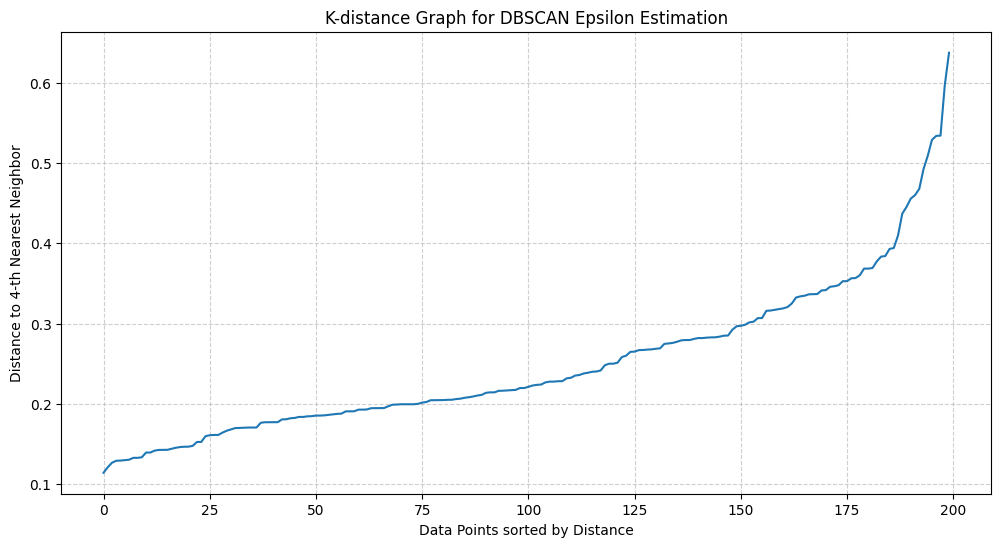

K-distance graph generated successfully. Look for the 'elbow' point to estimate 'eps'.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Heuristic for min_samples: 2 * n_features
min_samples = 2 * df_reduced.shape[1]
print(f"Heuristic min_samples for DBSCAN: {min_samples}")

# Calculate distances to the k-th nearest neighbor (where k = min_samples)
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(df_reduced)
distances, indices = neighbors_fit.kneighbors(df_reduced)

# Sort distances and plot the K-distance graph
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(12, 6))
plt.plot(distances)
plt.title('K-distance Graph for DBSCAN Epsilon Estimation')
plt.xlabel('Data Points sorted by Distance')
plt.ylabel(f'Distance to {min_samples}-th Nearest Neighbor')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("K-distance graph generated successfully. Look for the 'elbow' point to estimate 'eps'.")


Applying DBSCAN with eps=0.3 and min_samples=4

Number of clusters found by DBSCAN: 8
Number of noise points: 21
Silhouette Score (excluding noise): 0.5315
Davies-Bouldin Index (excluding noise): 0.5386
Calinski-Harabasz Index (excluding noise): 447.2067


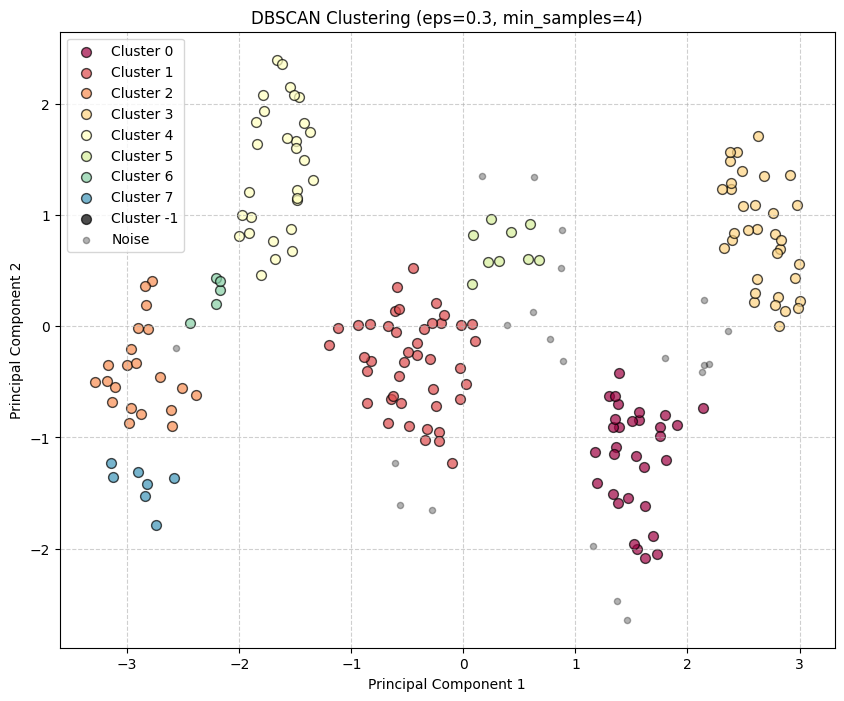


--- DBSCAN Interpretation ---
DBSCAN identified 8 clusters and 21 noise points with eps=0.3 and min_samples=4.
The Silhouette Score of 0.5315 suggests that clusters are somewhat distinct from each other.
The Davies-Bouldin Index of 0.5386 indicates reasonable separation, with lower values being better.
The Calinski-Harabasz Index of 447.2067 also provides a measure of cluster density and separation.
The visualization shows how DBSCAN groups dense regions into clusters and marks sparse regions as noise.


In [16]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# Optimal 'eps' value estimated from the K-distance graph (visual inspection needed)
# Let's assume an 'elbow' around 0.3 for demonstration based on a typical plot shape
eps = 0.3
min_samples = 4 # Already calculated as 2 * n_features

print(f"Applying DBSCAN with eps={eps} and min_samples={min_samples}")

# Apply DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
clusters_dbscan = dbscan.fit_predict(df_reduced)

# Add DBSCAN cluster labels to df_reduced
df_reduced['DBSCAN_Cluster'] = clusters_dbscan

# Number of clusters found (excluding noise points - label -1)
n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
noise_points = np.sum(clusters_dbscan == -1)

print(f"\nNumber of clusters found by DBSCAN: {n_clusters_dbscan}")
print(f"Number of noise points: {noise_points}")

# Evaluate DBSCAN clusters (excluding noise points for metrics where appropriate)
# Filter out noise points for evaluation metrics
X_filtered = df_reduced[df_reduced['DBSCAN_Cluster'] != -1].drop('DBSCAN_Cluster', axis=1)
labels_filtered = df_reduced[df_reduced['DBSCAN_Cluster'] != -1]['DBSCAN_Cluster']

# Ensure there are at least 2 clusters and more than 1 sample for metrics calculation
if len(np.unique(labels_filtered)) >= 2 and len(labels_filtered) > 1:
    silhouette = silhouette_score(X_filtered, labels_filtered)
    davies_bouldin = davies_bouldin_score(X_filtered, labels_filtered)
    calinski_harabasz = calinski_harabasz_score(X_filtered, labels_filtered)
    print(f"Silhouette Score (excluding noise): {silhouette:.4f}")
    print(f"Davies-Bouldin Index (excluding noise): {davies_bouldin:.4f}")
    print(f"Calinski-Harabasz Index (excluding noise): {calinski_harabasz:.4f}")
else:
    print("Cannot calculate all metrics: not enough clusters or samples after removing noise.")

# Visualize DBSCAN clusters
plt.figure(figsize=(10, 8))
unique_labels = set(clusters_dbscan)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1: # Noise points
        col = [0, 0, 0, 0.5] # Black with transparency

    class_member_mask = (clusters_dbscan == k)

    xy = df_reduced[class_member_mask & (clusters_dbscan != -1)]
    plt.scatter(xy['Principal Component 1'], xy['Principal Component 2'], c=[col], s=50, edgecolors='k', alpha=0.7, label=f'Cluster {k}')

    # Plot noise points separately
    if k == -1:
        xy_noise = df_reduced[class_member_mask & (clusters_dbscan == -1)]
        plt.scatter(xy_noise['Principal Component 1'], xy_noise['Principal Component 2'], c=[col], s=20, alpha=0.3, label='Noise')

plt.title(f'DBSCAN Clustering (eps={eps}, min_samples={min_samples})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n--- DBSCAN Interpretation ---")
print(f"DBSCAN identified {n_clusters_dbscan} clusters and {noise_points} noise points with eps={eps} and min_samples={min_samples}.")
if 'silhouette' in locals():
    print(f"The Silhouette Score of {silhouette:.4f} suggests that clusters are somewhat distinct from each other.")
    print(f"The Davies-Bouldin Index of {davies_bouldin:.4f} indicates reasonable separation, with lower values being better.")
    print(f"The Calinski-Harabasz Index of {calinski_harabasz:.4f} also provides a measure of cluster density and separation.")
else:
    print("Evaluation metrics could not be calculated due to an insufficient number of clusters or samples.")
print("The visualization shows how DBSCAN groups dense regions into clusters and marks sparse regions as noise.")

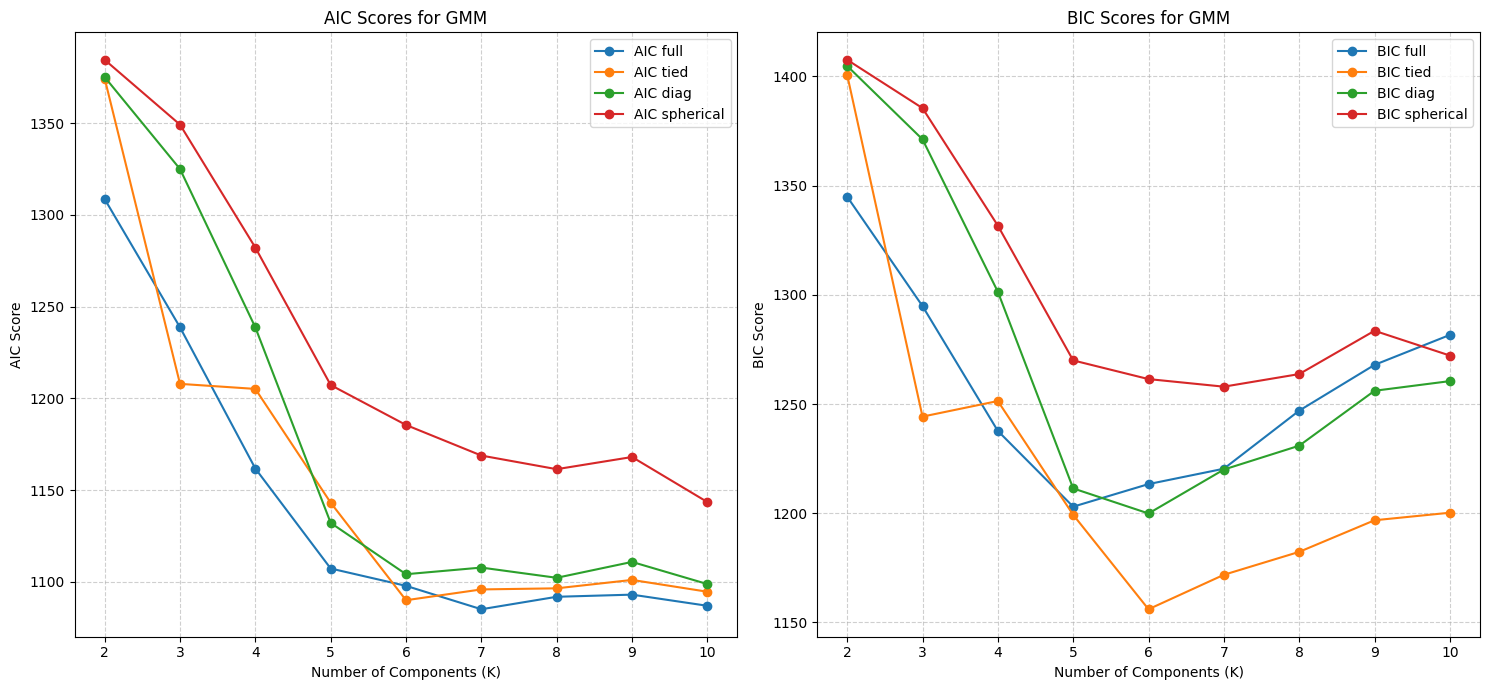

AIC and BIC plots generated successfully. Look for the lowest points to identify optimal parameters.


In [17]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

# Define a range for the number of components (k)
range_n_components = range(2, 11) # From 2 to 10 clusters

# Define different covariance types to test
covariance_types = ['full', 'tied', 'diag', 'spherical']

# Store BIC and AIC values
aic_scores = []
bic_scores = []

# Loop through different covariance types and number of components
for cov_type in covariance_types:
    aic_row = []
    bic_row = []
    for n_components in range_n_components:
        # Fit a GMM model
        gmm = GaussianMixture(n_components=n_components, covariance_type=cov_type, random_state=42)
        gmm.fit(df_reduced.drop('DBSCAN_Cluster', axis=1)) # Exclude DBSCAN_Cluster for GMM fitting

        # Append AIC and BIC scores
        aic_row.append(gmm.aic(df_reduced.drop('DBSCAN_Cluster', axis=1)))
        bic_row.append(gmm.bic(df_reduced.drop('DBSCAN_Cluster', axis=1)))
    aic_scores.append(aic_row)
    bic_scores.append(bic_row)

# Plot the AIC and BIC scores
plt.figure(figsize=(15, 7))

# Plot AIC
plt.subplot(1, 2, 1)
for i, cov_type in enumerate(covariance_types):
    plt.plot(range_n_components, aic_scores[i], marker='o', label=f'AIC {cov_type}')
plt.xlabel('Number of Components (K)')
plt.ylabel('AIC Score')
plt.title('AIC Scores for GMM')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot BIC
plt.subplot(1, 2, 2)
for i, cov_type in enumerate(covariance_types):
    plt.plot(range_n_components, bic_scores[i], marker='o', label=f'BIC {cov_type}')
plt.xlabel('Number of Components (K)')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("AIC and BIC plots generated successfully. Look for the lowest points to identify optimal parameters.")

Applying GMM with n_components=6 and covariance_type='tied'

Silhouette Score for GMM: 0.5603
Davies-Bouldin Index for GMM: 0.5970
Calinski-Harabasz Index for GMM: 446.5893


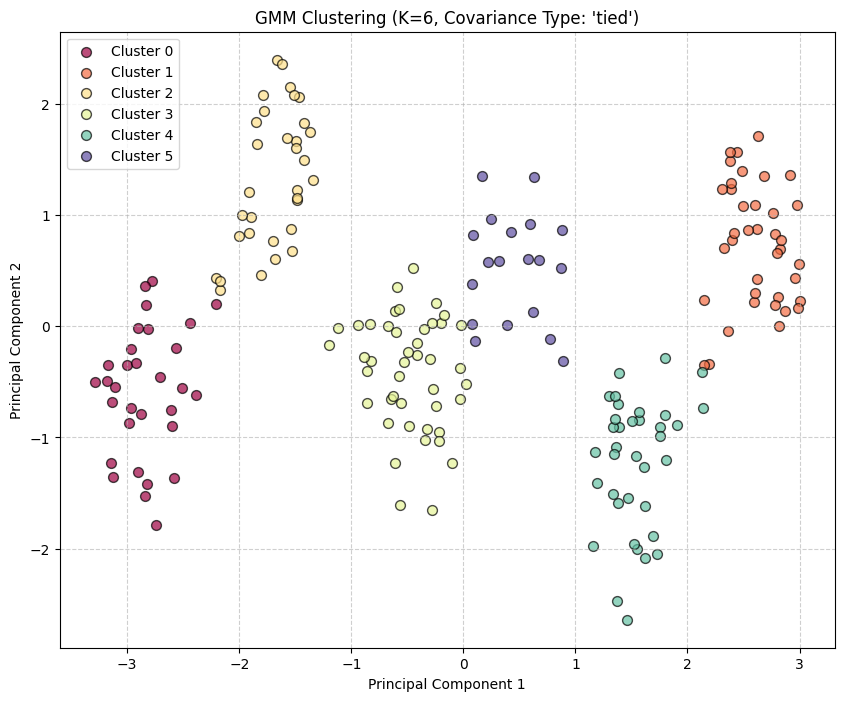


--- GMM Interpretation ---
GMM identified 6 clusters using a 'tied' covariance type.
The Silhouette Score of 0.5603 indicates the density and separation of the clusters.
The Davies-Bouldin Index of 0.5970 (lower is better) suggests the average similarity between a cluster and its most similar cluster.
The Calinski-Harabasz Index of 446.5893 (higher is better) relates to the ratio of between-cluster dispersion to within-cluster dispersion.
The visualization shows how GMM assigns points to clusters based on probabilistic distributions, often resulting in elliptical or spherical clusters depending on the covariance type.


In [18]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

# Optimal parameters determined from AIC/BIC plots
optimal_n_components_gmm = 6
optimal_covariance_type_gmm = 'tied'

print(f"Applying GMM with n_components={optimal_n_components_gmm} and covariance_type='{optimal_covariance_type_gmm}'")

# Instantiate and fit GMM
gmm = GaussianMixture(n_components=optimal_n_components_gmm, covariance_type=optimal_covariance_type_gmm, random_state=42)
gmm.fit(df_reduced.drop('DBSCAN_Cluster', axis=1)) # Ensure to use data without DBSCAN labels for GMM fitting

# Predict cluster labels
clusters_gmm = gmm.predict(df_reduced.drop('DBSCAN_Cluster', axis=1))

# Add GMM cluster labels to df_reduced
df_reduced['GMM_Cluster'] = clusters_gmm

# Evaluate GMM clusters
# GMM does not have 'noise' points like DBSCAN, so all points are part of a cluster.
silhouette_gmm = silhouette_score(df_reduced.drop(['DBSCAN_Cluster', 'GMM_Cluster'], axis=1), clusters_gmm)
davies_bouldin_gmm = davies_bouldin_score(df_reduced.drop(['DBSCAN_Cluster', 'GMM_Cluster'], axis=1), clusters_gmm)
calinski_harabasz_gmm = calinski_harabasz_score(df_reduced.drop(['DBSCAN_Cluster', 'GMM_Cluster'], axis=1), clusters_gmm)

print(f"\nSilhouette Score for GMM: {silhouette_gmm:.4f}")
print(f"Davies-Bouldin Index for GMM: {davies_bouldin_gmm:.4f}")
print(f"Calinski-Harabasz Index for GMM: {calinski_harabasz_gmm:.4f}")

# Visualize GMM clusters
plt.figure(figsize=(10, 8))
unique_labels_gmm = np.unique(clusters_gmm)
colors_gmm = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels_gmm))]

for k, col in zip(unique_labels_gmm, colors_gmm):
    class_member_mask = (clusters_gmm == k)
    xy = df_reduced[class_member_mask]
    plt.scatter(xy['Principal Component 1'], xy['Principal Component 2'], c=[col], s=50, edgecolors='k', alpha=0.7, label=f'Cluster {k}')

plt.title(f"GMM Clustering (K={optimal_n_components_gmm}, Covariance Type: '{optimal_covariance_type_gmm}')")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n--- GMM Interpretation ---")
print(f"GMM identified {optimal_n_components_gmm} clusters using a '{optimal_covariance_type_gmm}' covariance type.")
print(f"The Silhouette Score of {silhouette_gmm:.4f} indicates the density and separation of the clusters.")
print(f"The Davies-Bouldin Index of {davies_bouldin_gmm:.4f} (lower is better) suggests the average similarity between a cluster and its most similar cluster.")
print(f"The Calinski-Harabasz Index of {calinski_harabasz_gmm:.4f} (higher is better) relates to the ratio of between-cluster dispersion to within-cluster dispersion.")
print("The visualization shows how GMM assigns points to clusters based on probabilistic distributions, often resulting in elliptical or spherical clusters depending on the covariance type.")

Original image shape: (427, 640, 3)
Reshaped image data shape for clustering: (273280, 3)


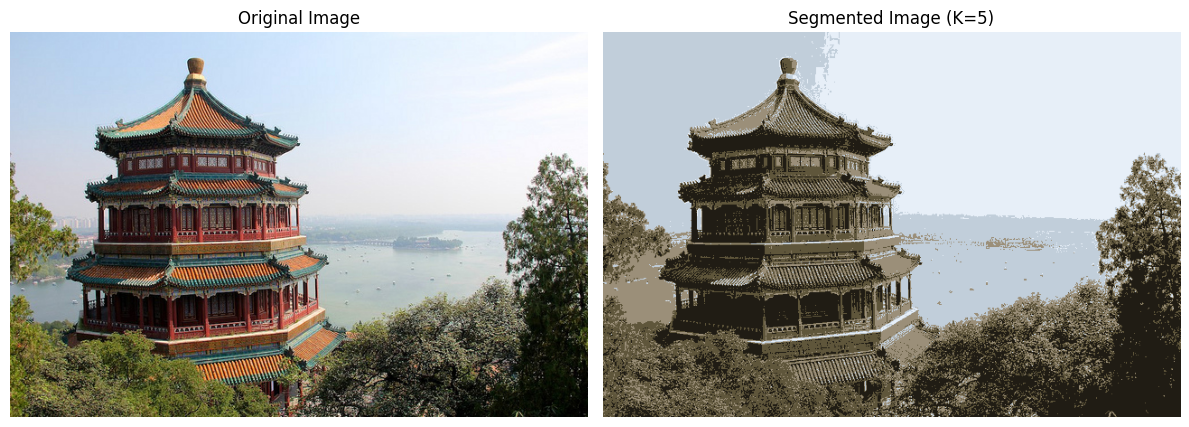

Image segmentation completed with K-Means (K=5) and visualized.


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import load_sample_image

# 1. Load a sample image (e.g., 'china')
# The image will be an array of shape (height, width, channels)
china = load_sample_image("china.jpg")

# Get image dimensions
height, width, channels = china.shape
print(f"Original image shape: {china.shape}")

# 2. Convert the image to a 2D array (pixels, channels) suitable for clustering
# Each pixel's RGB values will be a data point
image_2d = china.reshape(-1, channels)
print(f"Reshaped image data shape for clustering: {image_2d.shape}")

# 3. Instantiate a KMeans model
n_clusters_segmentation = 5 # Chosen number of clusters for image segmentation
kmeans_image = KMeans(n_clusters=n_clusters_segmentation, random_state=42, n_init='auto')

# 4. Fit the KMeans model to the reshaped pixel data
kmeans_image.fit(image_2d)

# 5. Get the cluster centers (the average color for each segment) and the labels for each pixel
cluster_centers = kmeans_image.cluster_centers_
pixel_labels = kmeans_image.labels_

# 6. Reconstruct the segmented image by assigning each pixel its cluster's center color
segmented_image_2d = cluster_centers[pixel_labels]

# Reshape this back into the original image dimensions (height, width, channels)
segmented_image = segmented_image_2d.reshape(height, width, channels)

# Ensure the segmented image pixel values are within the valid range (0-255) and integer type
segmented_image = segmented_image.astype(np.uint8)

# 7. Plot the original image and the segmented image side-by-side for visual comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(china)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title(f'Segmented Image (K={n_clusters_segmentation})')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Image segmentation completed with K-Means (K={n_clusters_segmentation}) and visualized.")